In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.0 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Import Dataset from kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abtinzandi/obstacle-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'obstacle-detection-dataset' dataset.
Path to dataset files: /kaggle/input/obstacle-detection-dataset


# Move the dataset to Content(cache)

In [ ]:
import shutil

# Your cached path from Kagglehub
source_path = path

# Your new Google Drive path
destination_path = '/content/drive/MyDrive/Projects/Obstacle-Detection/obstaacle_detection_dataset'

try:
    # We add dirs_exist_ok=True to prevent any FileExistsError!
    shutil.copytree(source_path, destination_path, dirs_exist_ok=True)
    print(f"Success! Dataset copied to: {destination_path}")

except Exception as e:
    print(f"An error occurred: {e}")

Success! Dataset copied to: /content/drive/MyDrive/Projects/Obstacle-Detection/obstaacle_detection_dataset


In [ ]:
import shutil

source = path
destination = "/content/ROD-Dataset"

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Dataset replaced successfully!")

Dataset replaced successfully!


In [ ]:
from ultralytics import YOLO
import os

data_path = '/content/ROD-Dataset/ROD-Dataset/dataset/data.yaml'
checkpoint = "/content/drive/MyDrive/Projects/Obstacle-Detection/yolov8_obstacle_detection/weights/last.pt"

if os.path.exists(checkpoint):

    print("Resuming training from checkpoint...")

    model = YOLO(checkpoint)

    results = model.train(resume=True)

else:

    print("Starting new training...")

    model = YOLO("yolov8n.pt")

    results = model.train(
        data=data_path,
        epochs=50,
        imgsz=512,
        batch=8,
        workers=2,
        patience=15,
        project="/content/drive/MyDrive/Projects/Obstacle-Detection",
        name="yolov8_obstacle_detection"
    )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Resuming training from checkpoint...
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ROD-Dataset/ROD-Dataset/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, free

# Model Validattion

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Projects/Obstacle-Detection/yolov8_obstacle_detection/weights/best.pt")


data_path = '/content/drive/MyDrive/Projects/Obstacle-Detection/obstaacle_detection_dataset/ROD-Dataset/dataset/data.yaml'

metrics = model.val(data=data_path)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 16.3±30.6 ms, read: 3.0±2.7 MB/s, size: 33.2 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1pbYWaJtPBgQ5RVVVltV-GnsoEyVfj0CA/Projects/Obstacle-Detection/obstaacle_detection_dataset/ROD-Dataset/dataset/valid/labels... 3511 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3511/3511 42.3it/s 1:23
val: New cache created: /content/drive/.shortcut-targets-by-id/1pbYWaJtPBgQ5RVVVltV-GnsoEyVfj0CA/Projects/Obstacle-Detection/obstaacle_detection_dataset/ROD-Dataset/dataset/valid/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 821, len(boxes) = 5572. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Ima

In [ ]:
import matplotlib.pyplot as plt

metrics.confusion_matrix.plot()
plt.show()

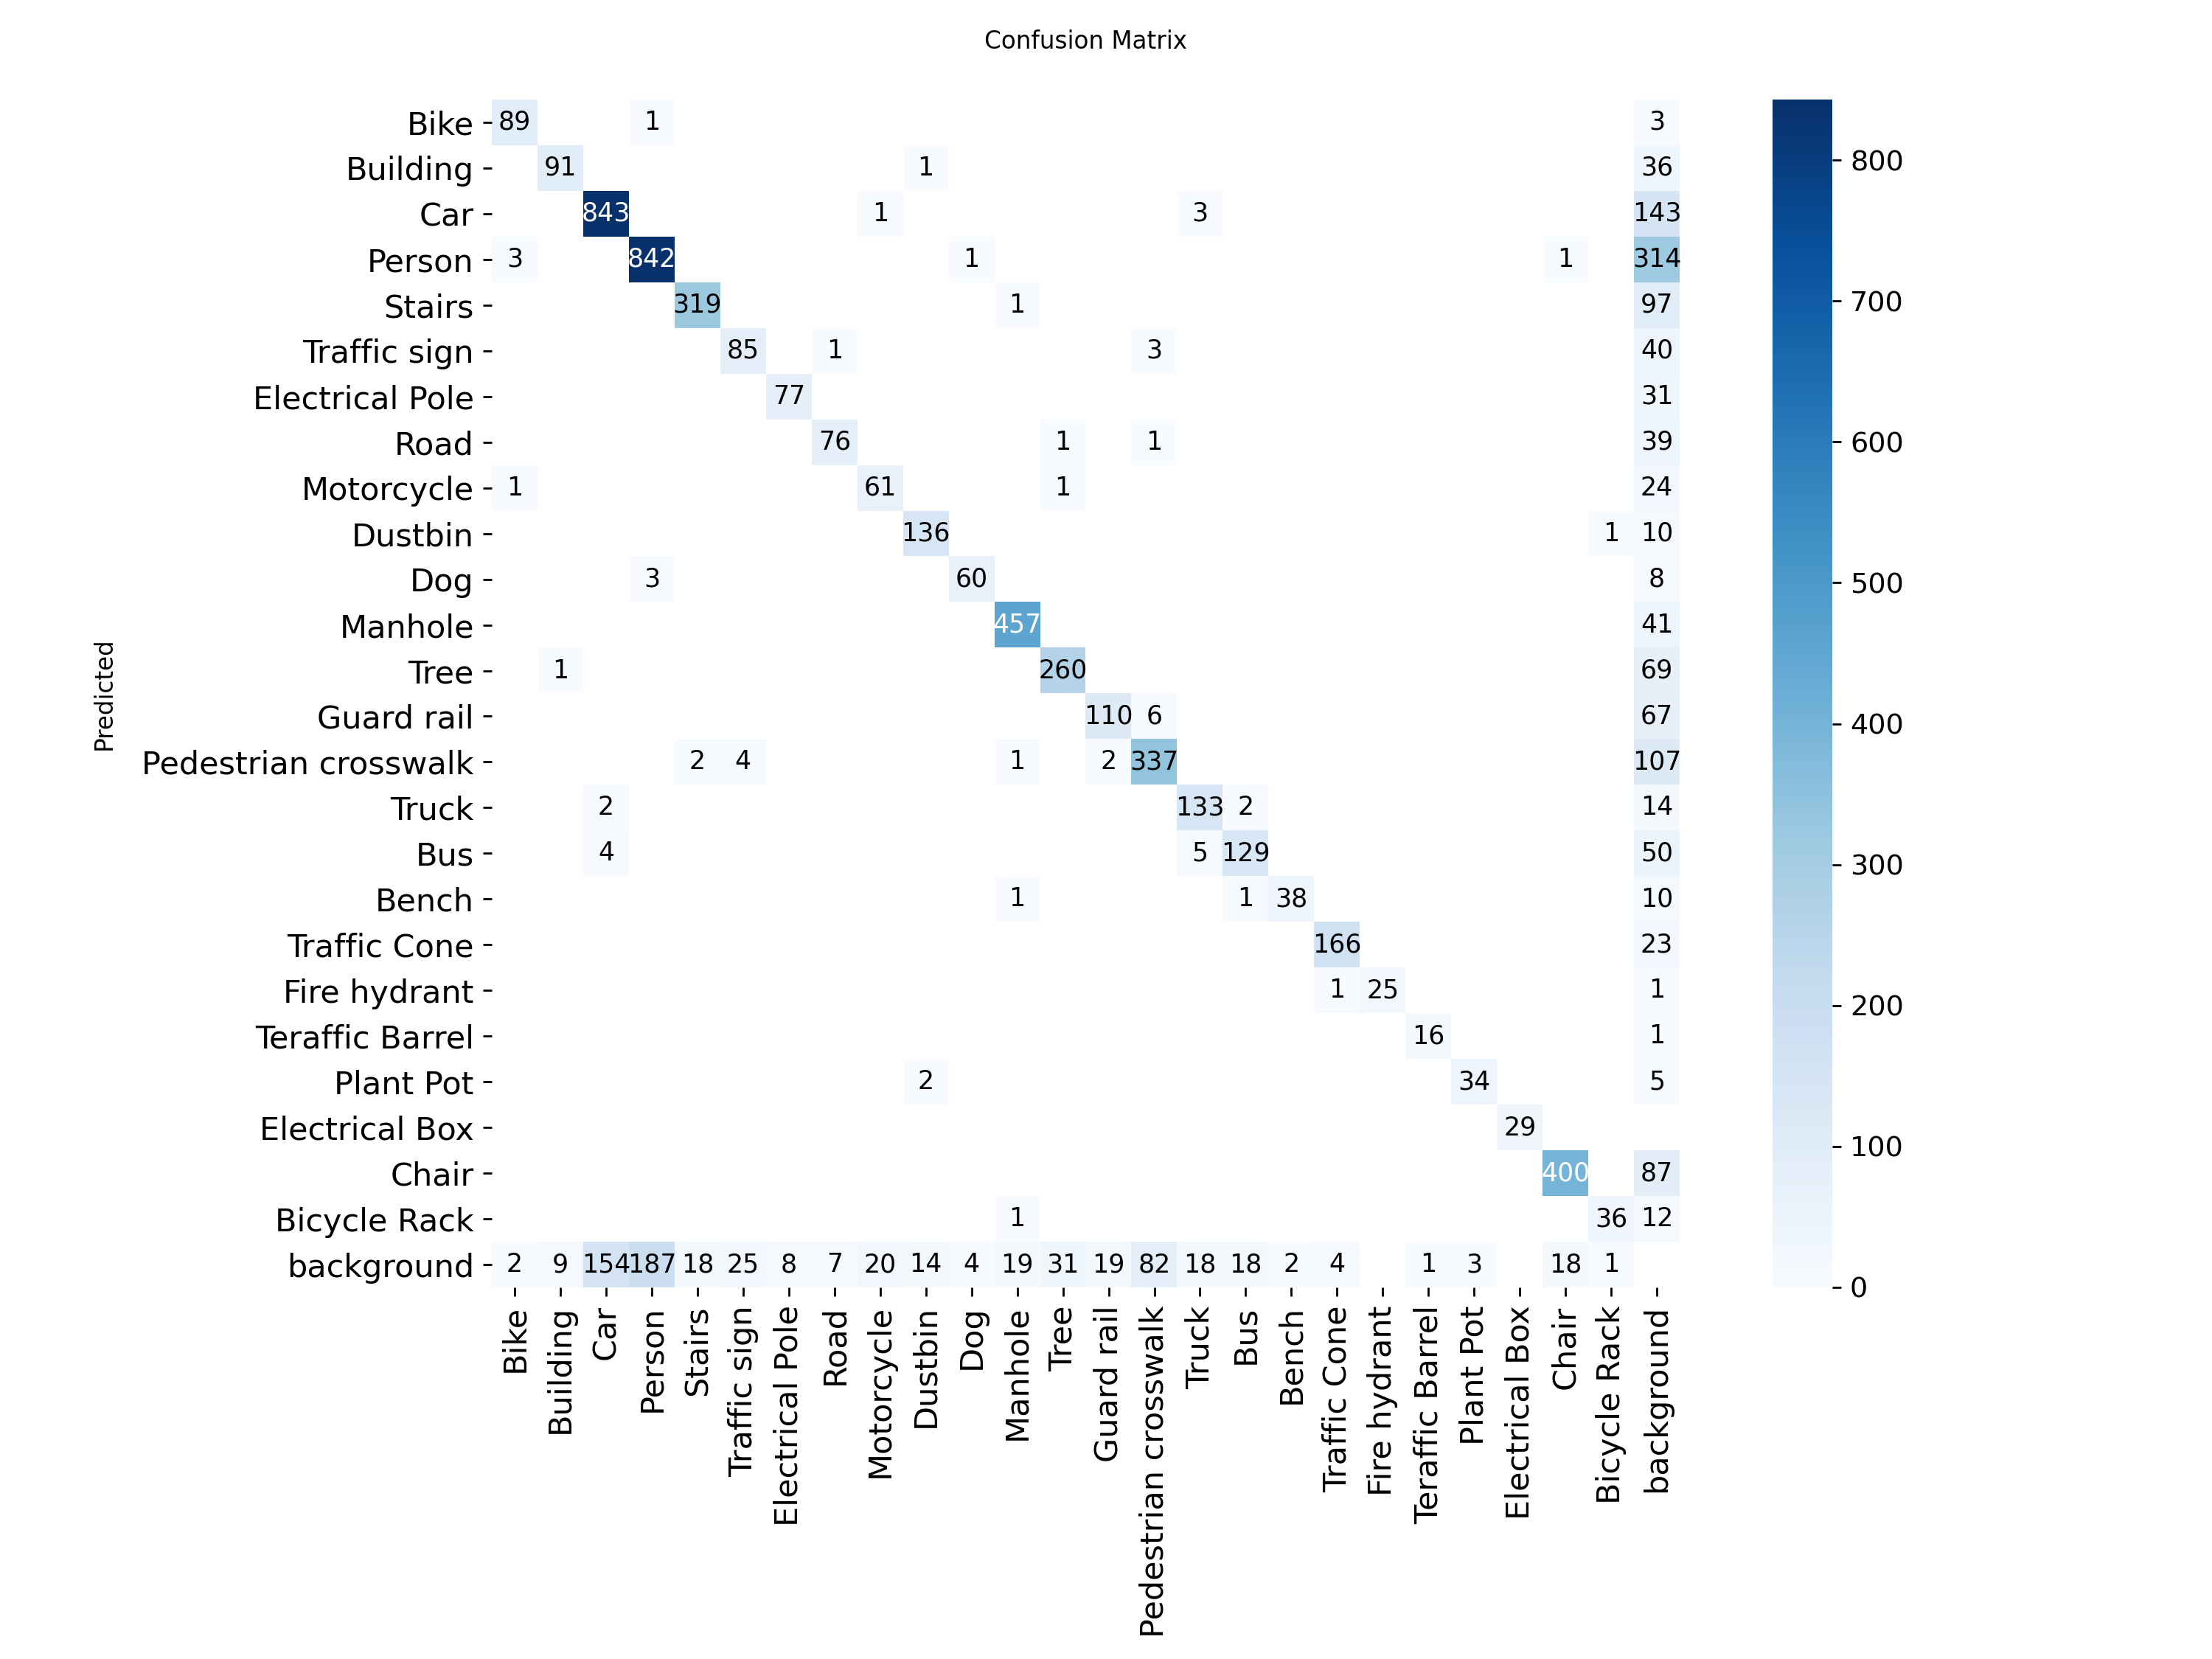

In [ ]:
from IPython.display import Image, display

display(Image("/content/runs/detect/val/confusion_matrix.png"))

# Testing

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/Projects/Obstacle-Detection/yolov8_obstacle_detection/weights/best.pt")

results = model.predict(
    source='/content/ROD-Dataset/ROD-Dataset/dataset/test/images/IMG_19256.jpg',
    conf=0.25,
    save=True
)


image 1/1 /content/ROD-Dataset/ROD-Dataset/dataset/test/images/IMG_19256.jpg: 512x512 2 Persons, 8.5ms
Speed: 1.8ms preprocess, 8.5ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/runs/detect/predict-8


In [ ]:
results = model.predict(
    source="/content/ROD-Dataset/ROD-Dataset/dataset/test/images",
    conf=0.25,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1629 /content/ROD-Dataset/ROD-Dataset/dataset/test/images/IMG_19187.jpg: 512x512 1 Car, 9.1ms
image 2/1629 /content/ROD-Dataset/ROD-Dataset/dataset/test/images/IMG_19188.jpg: 512x512 1 Manhole, 8.0ms
image 3/1629 /content/ROD-Dataset/ROD-Dataset/dataset/test/images/IMG_19189.jpg: 512x512 1 Car, 6.1ms
image 4/1629 /content/ROD-Dataset/ROD-Dataset/dataset/test/images/IMG_19190.jpg: 512x512 1 Car, 6.8ms
image 5/1629 /content/ROD-Dataset/ROD-Dataset/

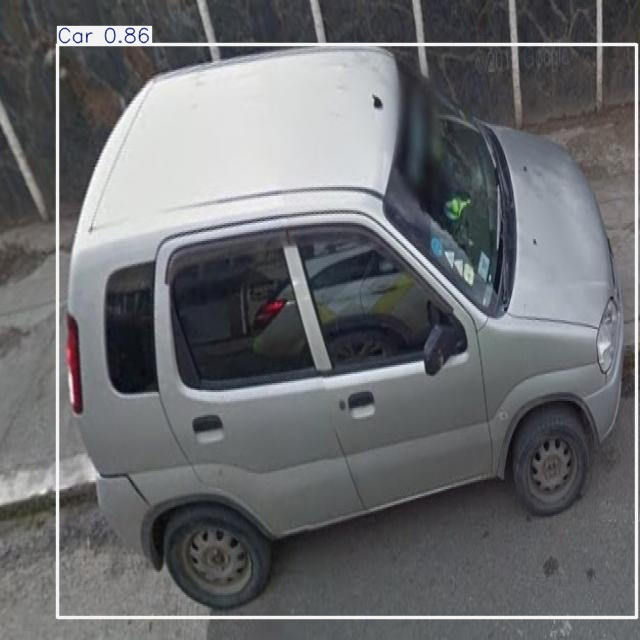

In [ ]:
import glob
from IPython.display import Image, display

imgs = glob.glob("/content/runs/detect/predict/*.jpg")

for img in imgs[:10]:
    display(Image(filename=img))

Model Deployment

In [4]:
from ultralytics import YOLO
best_pt = '/content/drive/MyDrive/Projects/Obstacle-Detection/yolov8_obstacle_detection/weights/best.pt'

model = YOLO(best_pt)
model.export(format="onnx")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Projects/Obstacle-Detection/yolov8_obstacle_detection/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 29, 5376) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolv

'/content/drive/MyDrive/Projects/Obstacle-Detection/yolov8_obstacle_detection/weights/best.onnx'

WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.

image 1/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg: 512x384 3 Persons, 138.1ms
image 2/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/zidane.jpg: 288x512 3 Persons, 96.6ms
Speed: 7.2ms preprocess, 117.3ms inference, 21.8ms postprocess per image at shape (1, 3, 288, 512)


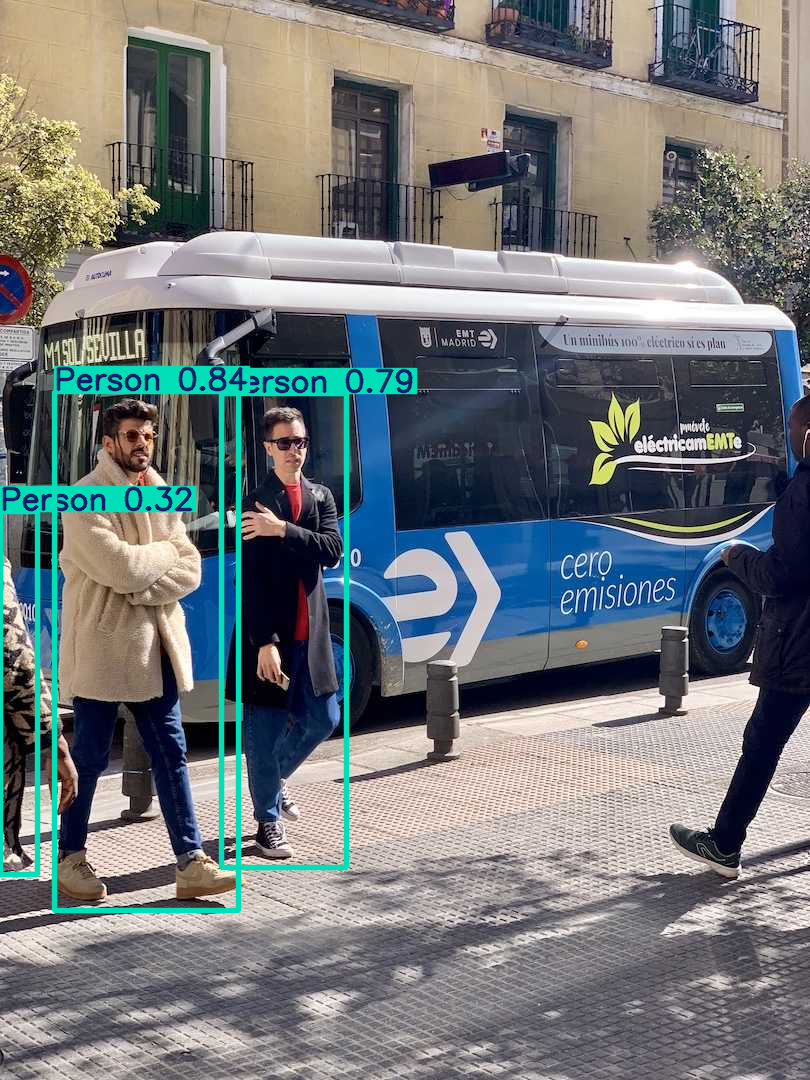

In [5]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load model
model = YOLO("/content/drive/MyDrive/Projects/Obstacle-Detection/yolov8_obstacle_detection/weights/best.pt", task="detect")

# Read image
img = cv2.imread("/content/drive/MyDrive/Projects/Obstacle-Detection/obstaacle_detection_dataset/ROD-Dataset/dataset/test/images/IMG_19187.jpg")

# Run inference
results = model(img)

# Draw predictions
annotated = results[0].plot()

# Show image in Colab
cv2_imshow(annotated)

In [10]:
# 1. Go to the main Colab folder and clone your GitHub repository
%cd /content/drive/MyDrive/Projects/Obstacle-Detection
!git clone https://github.com/isamadafridi/obstacle-detection.git
# 2. Move INTO your newly downloaded GitHub repository (This is the Git Destination)
# %cd /content/Obstacle-Detection

# 3. Copy everything from your Drive folder INTO the GitHub repository
# The /* means "copy all the files inside this folder"
# The . at the end means "paste them right here"
!cp -r /content/drive/MyDrive/Projects/Obstacle-Detection/obstacle-detection/* .

# 4. Configure your Git identity
!git config --global user.name "isamadafridi"
!git config --global user.email "isamadafridi@gmail.com"

# 5. Stage, commit, and push everything to GitHub
!git add .
!git commit -m "Initial upload of Obstacle Detection project from Google Drive"
!git push origin main

/content/drive/.shortcut-targets-by-id/1pbYWaJtPBgQ5RVVVltV-GnsoEyVfj0CA/Projects/Obstacle-Detection
fatal: destination path 'obstacle-detection' already exists and is not an empty directory.
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
